# IMDb Sentiment Analysis with TF-IDF and χ² Feature Selection

## Overview

This project investigates sentiment classification of IMDb movie reviews using
traditional machine learning and TF-IDF text representation.

The study compares multiple baseline classifiers and evaluates whether
χ²-based feature selection can substantially reduce the dimensionality of the
TF-IDF feature space while preserving classification performance.

## Objectives

- Convert movie reviews into numerical representations using TF-IDF.
- Compare Logistic Regression, Naive Bayes, and Linear SVM as baseline models.
- Apply χ² feature selection with different values of K.
- Analyze the trade-off between the number of features and classification performance.
- Evaluate the final model using accuracy, F1-score, and confusion matrices.
- Test the final pipeline on an unseen movie review.

## Research Question

> How much can the TF-IDF feature space be reduced using χ² feature selection
> without significantly degrading sentiment classification performance?

In [1]:
import os
import pandas as pd

base_path = "data/aclImdb_v1/aclImdb/train"

reviews = []
labels = []

for label_name in ["pos", "neg"]:
    folder = os.path.join(base_path, label_name)

    for filename in os.listdir(folder)[:100]:
        file_path = os.path.join(folder, filename)

        with open(file_path, "r", encoding="utf-8") as f:
            reviews.append(f.read())

        labels.append(1 if label_name == "pos" else 0)

sample_df = pd.DataFrame({
    "review": reviews,
    "sentiment": labels
})

sample_df.shape

(200, 2)

In [2]:
sample_df.head()

,review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [3]:
sample_df["sentiment"].value_counts()

sentiment
1    100
0    100
Name: count, dtype: int64

In [4]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     200 non-null    object
 1   sentiment  200 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.3+ KB


## 1. Dataset Loading

The IMDb dataset is organized into separate folders for positive and negative reviews.
The `load_reviews()` function reads the review text files and assigns:

- `1` → Positive sentiment
- `0` → Negative sentiment

The reviews are then stored in a Pandas DataFrame for further preprocessing and analysis.

In [5]:
def load_reviews(path):
    reviews = []
    labels = []

    for label_name, label in [("pos", 1), ("neg", 0)]:
        folder = os.path.join(path, label_name)

        for filename in os.listdir(folder):
            if filename.endswith(".txt"):
                file_path = os.path.join(folder, filename)

                with open(file_path, "r", encoding="utf-8") as f:
                    reviews.append(f.read())

                labels.append(label)

    return pd.DataFrame({
        "review": reviews,
        "sentiment": labels
    })

## 2. Exploratory Data Analysis

Before preprocessing, the dataset is inspected to understand its structure,
class distribution, and review characteristics.

The main checks include:

- Number of reviews and features
- Distribution of positive and negative sentiments
- Presence of duplicate reviews
- Review length statistics

In [6]:
train_path = "data/aclImdb_v1/aclImdb/train"

train_df = load_reviews(train_path)

print(train_df.shape)

(25000, 2)


In [7]:
train_df["sentiment"].value_counts()

sentiment
1    12500
0    12500
Name: count, dtype: int64

In [8]:
train_df.head()

,review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [9]:
train_df["review"].str.len().describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review, dtype: float64

In [10]:
train_df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [11]:
'''
since mean>median
That suggests the distribution is right-skewed: most reviews are relatively
moderate in length, while a smaller number of very long reviews pull the mean upward.

'''

'\nsince mean>median\nThat suggests the distribution is right-skewed: most reviews are relatively\nmoderate in length, while a smaller number of very long reviews pull the mean upward.\n\n'

In [12]:
train_df["review"].duplicated().sum()


np.int64(96)

In [13]:
train_df.duplicated().sum()


np.int64(96)

In [14]:
#96 duplicate reviews out of 25k

In [15]:
duplicate_reviews = train_df[train_df["review"].duplicated(keep=False)]

duplicate_reviews.groupby("review")["sentiment"].nunique().value_counts()

sentiment
1    92
Name: count, dtype: int64

In [16]:
train_df[train_df["review"].duplicated(keep=False)].sort_values("review").head(10)

,review,sentiment
24842,'Dead Letter Office' is a low-budget film abou...,0
18447,'Dead Letter Office' is a low-budget film abou...,0
8131,".......Playing Kaddiddlehopper, Col San Fernan...",1
11742,".......Playing Kaddiddlehopper, Col San Fernan...",1
21983,"<br /><br />Back in his youth, the old man had...",0
21984,"<br /><br />Back in his youth, the old man had...",0
8576,A have a female friend who is currently being ...,1
8554,A have a female friend who is currently being ...,1
5070,"A longtime fan of Bette Midler, I must say her...",1
12123,"A longtime fan of Bette Midler, I must say her...",1


In [17]:
train_df = train_df.drop_duplicates(subset="review").reset_index(drop=True)

In [18]:
train_df.shape

(24904, 2)

In [19]:

print(train_df["sentiment"].value_counts())

sentiment
1    12472
0    12432
Name: count, dtype: int64


## 3. Text Preprocessing

Raw movie reviews contain noise such as HTML tags, punctuation, and inconsistent
capitalization. The reviews are cleaned before converting them into numerical
features.

The preprocessing pipeline includes:

- Converting text to lowercase
- Removing HTML tags
- Removing unnecessary punctuation and special characters
- Normalizing whitespace

The cleaned reviews are then used for TF-IDF vectorization.

In [20]:
import re

In [21]:
def preprocess_text(text):
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r"<br\s*/?>", " ", text)
    
    return text

In [22]:
sample = train_df["review"].iloc[0]

print("BEFORE:")
print(sample[:500])

print("\nAFTER:")
print(preprocess_text(sample)[:500])

BEFORE:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a s

AFTER:
bromwell high is a cartoon comedy. it ran at the same time as some other programs about school life, such as "teachers". my 35 years in the teaching profession lead me to believe that bromwell high's satire is much closer to reality than is "teachers". the scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools i knew and their students. when i saw the epi

In [23]:
train_df["clean_review"] = train_df["review"].apply(preprocess_text)

In [24]:
train_df[["review", "clean_review"]].head(2)

,review,clean_review
0,Bromwell High is a cartoon comedy. It ran at t...,bromwell high is a cartoon comedy. it ran at t...
1,Homelessness (or Houselessness as George Carli...,homelessness (or houselessness as george carli...


In [25]:
train_df["clean_review"].isnull().sum()

np.int64(0)

In [26]:
test_path = "data/aclImdb_v1/aclImdb/test"

test_df = load_reviews(test_path)

print(test_df.shape)

(25000, 2)


In [27]:
test_df["clean_review"] = test_df["review"].apply(preprocess_text)

In [28]:
test_df["clean_review"].isnull().sum()

np.int64(0)

In [29]:
X_train = train_df["clean_review"]
y_train = train_df["sentiment"]

X_test = test_df["clean_review"]
y_test = test_df["sentiment"]

## 4. TF-IDF Vectorization

Machine learning models cannot directly process raw text, so the cleaned reviews
are converted into numerical feature vectors using Term Frequency-Inverse
Document Frequency (TF-IDF).

TF-IDF assigns higher importance to terms that are frequent in a particular
review but relatively uncommon across the entire collection of reviews.

The vectorizer is fitted only on the training data and then used to transform
both the training and test data to avoid data leakage.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [ ]:
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

## 5. Baseline Machine Learning Models

Three classical machine learning algorithms are evaluated using the full
TF-IDF feature representation:

1. **Logistic Regression** — used as the primary linear classification model.
2. **Naive Bayes** — a probabilistic baseline commonly used for text classification.
3. **Linear SVM** — a margin-based linear classifier suitable for high-dimensional text data.

These baseline models establish reference performance before applying feature selection.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

In [48]:
#Logistic Regression is currently our strongest baseline.

## 6. χ² Feature Selection

The TF-IDF representation initially contains 74,849 features. To investigate
whether all features are necessary, χ² statistical feature selection is applied.

The χ² test measures the association between each feature and the target
sentiment class. The top `K` features with the highest χ² scores are retained.

Different values of `K` are evaluated to study the trade-off between
dimensionality and predictive performance.

In [49]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=5000)

X_train_chi2 = selector.fit_transform(X_train_tfidf, y_train)
X_test_chi2 = selector.transform(X_test_tfidf)

print(X_train_chi2.shape)
print(X_test_chi2.shape)

(24904, 5000)
(25000, 5000)


In [50]:
lr_chi2 = LogisticRegression(max_iter=1000)

lr_chi2.fit(X_train_chi2, y_train)

y_pred_chi2 = lr_chi2.predict(X_test_chi2)

print("Accuracy:", accuracy_score(y_test, y_pred_chi2))
print(classification_report(y_test, y_pred_chi2))

Accuracy: 0.87908
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [52]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

k_values = [1000, 2000, 5000, 10000, 20000]

results = []

for k in k_values:
    selector = SelectKBest(score_func=chi2, k=k)

    X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
    X_test_selected = selector.transform(X_test_tfidf)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    results.append({
        "k": k,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

results

[{'k': 1000, 'accuracy': 0.86532, 'f1': 0.8667748189767737},
 {'k': 2000, 'accuracy': 0.87324, 'f1': 0.8740410986128224},
 {'k': 5000, 'accuracy': 0.87908, 'f1': 0.879566551133421},
 {'k': 10000, 'accuracy': 0.87984, 'f1': 0.8803663878932696},
 {'k': 20000, 'accuracy': 0.88212, 'f1': 0.8824632074342919}]

In [53]:
import pandas as pd

chi2_results = pd.DataFrame([
    {"k": 1000, "accuracy": 0.86532, "f1": 0.8667748189767737},
    {"k": 2000, "accuracy": 0.87324, "f1": 0.8740410986128224},
    {"k": 5000, "accuracy": 0.87908, "f1": 0.879566551133421},
    {"k": 10000, "accuracy": 0.87984, "f1": 0.8803663878932696},
    {"k": 20000, "accuracy": 0.88212, "f1": 0.8824632074342919}
])

chi2_results

,k,accuracy,f1
0,1000,0.86532,0.866775
1,2000,0.87324,0.874041
2,5000,0.87908,0.879567
3,10000,0.87984,0.880366
4,20000,0.88212,0.882463


In [54]:
chi2_results["feature_reduction_%"] = (
    (74849 - chi2_results["k"]) / 74849 * 100
).round(2)

chi2_results

,k,accuracy,f1,feature_reduction_%
0,1000,0.86532,0.866775,98.66
1,2000,0.87324,0.874041,97.33
2,5000,0.87908,0.879567,93.32
3,10000,0.87984,0.880366,86.64
4,20000,0.88212,0.882463,73.28


In [55]:
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# First reduce the vocabulary to 20,000 candidates using chi-square
chi_selector = SelectKBest(score_func=chi2, k=20000)

X_train_20k = chi_selector.fit_transform(X_train_tfidf, y_train)
X_test_20k = chi_selector.transform(X_test_tfidf)

print(X_train_20k.shape)

(24904, 20000)


In [56]:
import time
from sklearn.linear_model import LogisticRegression

start = time.time()

lr_20k = LogisticRegression(max_iter=1000)
lr_20k.fit(X_train_20k, y_train)

training_time_20k = time.time() - start

print("Training time:", training_time_20k, "seconds")

Training time: 0.6853194236755371 seconds


In [57]:
import time

start = time.time()

lr_full = LogisticRegression(max_iter=1000)
lr_full.fit(X_train_tfidf, y_train)

full_training_time = time.time() - start

print("Full features training time:", full_training_time, "seconds")

Full features training time: 0.666956901550293 seconds


In [58]:
k_values_extra = [30000, 40000]

extra_results = []

for k in k_values_extra:
    selector = SelectKBest(score_func=chi2, k=k)

    X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
    X_test_selected = selector.transform(X_test_tfidf)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)

    extra_results.append({
        "k": k,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

extra_results

[{'k': 30000, 'accuracy': 0.88204, 'f1': 0.8823365119897857},
 {'k': 40000, 'accuracy': 0.88212, 'f1': 0.8823505928380374}]

In [59]:
#χ² feature selection reduced the TF-IDF feature space from 74,849 to 20,000 
#features (73.28% reduction) while retaining
#99.91% of the baseline accuracy.

## 7. Feature Selection Results

The effect of χ² feature selection is evaluated using different values of `K`,
where `K` represents the number of features retained from the original
TF-IDF representation.

The models are evaluated using accuracy and F1-score. Feature reduction is
also calculated to quantify the dimensionality reduction achieved at each
value of `K`.

The goal is not simply to maximize accuracy, but to identify a feature count
that provides a strong balance between predictive performance and dimensionality.

In [61]:
import pandas as pd

all_chi2_results = pd.DataFrame([
    {"k": 1000,  "accuracy": 0.86532, "f1": 0.8667748},
    {"k": 2000,  "accuracy": 0.87324, "f1": 0.8740411},
    {"k": 5000,  "accuracy": 0.87908, "f1": 0.8795666},
    {"k": 10000, "accuracy": 0.87984, "f1": 0.8803664},
    {"k": 20000, "accuracy": 0.88212, "f1": 0.8824632},
    {"k": 30000, "accuracy": 0.88204, "f1": 0.8823365},
    {"k": 40000, "accuracy": 0.88212, "f1": 0.8823506},
    {"k": 74849, "accuracy": 0.88292, "f1": 0.88300}
])

all_chi2_results

,k,accuracy,f1
0,1000,0.86532,0.866775
1,2000,0.87324,0.874041
2,5000,0.87908,0.879567
3,10000,0.87984,0.880366
4,20000,0.88212,0.882463
5,30000,0.88204,0.882336
6,40000,0.88212,0.882351
7,74849,0.88292,0.883000


In [62]:
all_chi2_results["feature_reduction_%"] = (
    (74849 - all_chi2_results["k"]) / 74849 * 100
).round(2)

all_chi2_results

,k,accuracy,f1,feature_reduction_%
0,1000,0.86532,0.866775,98.66
1,2000,0.87324,0.874041,97.33
2,5000,0.87908,0.879567,93.32
3,10000,0.87984,0.880366,86.64
4,20000,0.88212,0.882463,73.28
5,30000,0.88204,0.882336,59.92
6,40000,0.88212,0.882351,46.56
7,74849,0.88292,0.883000,0.00


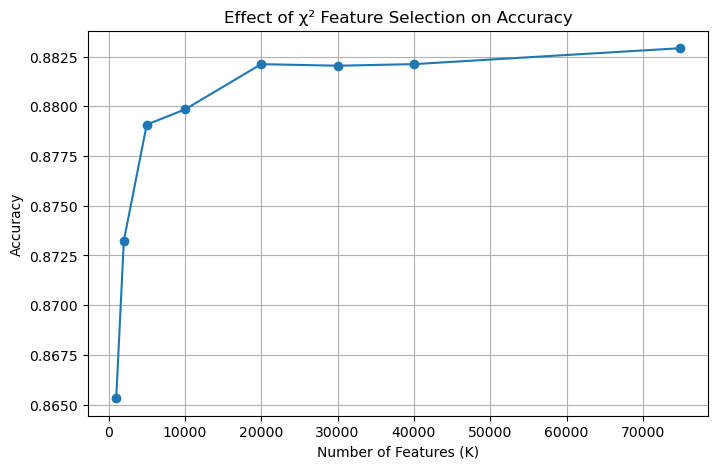

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    all_chi2_results["k"],
    all_chi2_results["accuracy"],
    marker="o"
)

plt.xlabel("Number of Features (K)")
plt.ylabel("Accuracy")
plt.title("Effect of χ² Feature Selection on Accuracy")
plt.grid(True)

plt.show()

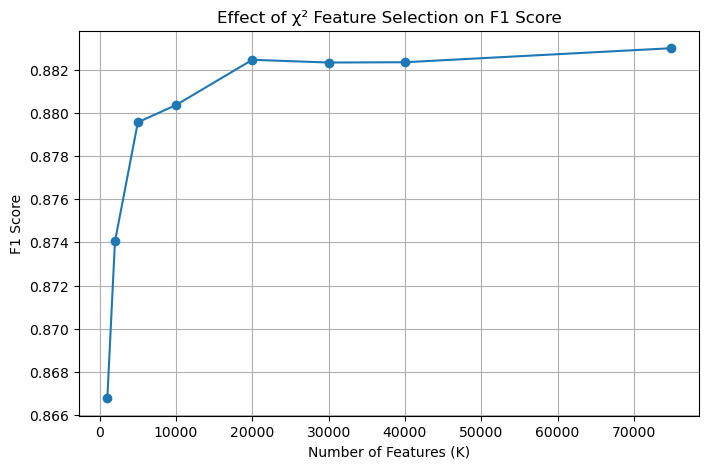

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    all_chi2_results["k"],
    all_chi2_results["f1"],
    marker="o"
)

plt.xlabel("Number of Features (K)")
plt.ylabel("F1 Score")
plt.title("Effect of χ² Feature Selection on F1 Score")
plt.grid(True)

plt.show()

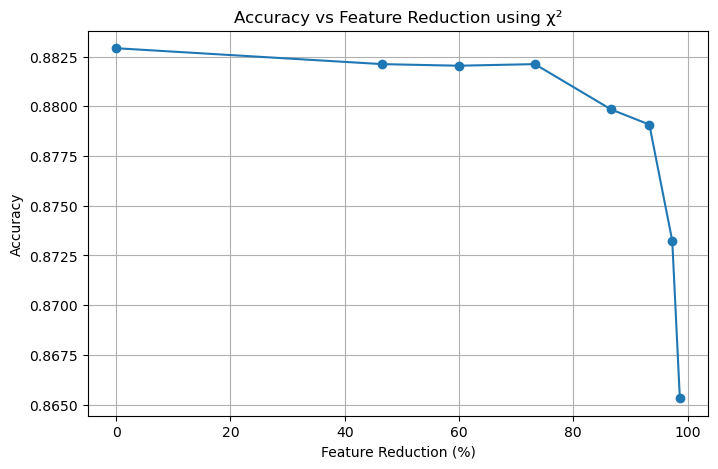

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    all_chi2_results["feature_reduction_%"],
    all_chi2_results["accuracy"],
    marker="o"
)

plt.xlabel("Feature Reduction (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Feature Reduction using χ²")
plt.grid(True)

plt.show()

In [66]:
best_accuracy = all_chi2_results.loc[
    all_chi2_results["accuracy"].idxmax()
]

print("Best accuracy:")
print(best_accuracy)

Best accuracy:
k                      74849.00000
accuracy                   0.88292
f1                         0.88300
feature_reduction_%        0.00000
Name: 7, dtype: float64


In [67]:
best_f1 = all_chi2_results.loc[
    all_chi2_results["f1"].idxmax()
]

print("Best F1:")
print(best_f1)

Best F1:
k                      74849.00000
accuracy                   0.88292
f1                         0.88300
feature_reduction_%        0.00000
Name: 7, dtype: float64


In [68]:
baseline_accuracy = all_chi2_results.loc[
    all_chi2_results["k"] == 74849, "accuracy"
].iloc[0]

all_chi2_results["accuracy_retention_%"] = (
    all_chi2_results["accuracy"] / baseline_accuracy * 100
).round(3)

all_chi2_results

,k,accuracy,f1,feature_reduction_%,accuracy_retention_%
0,1000,0.86532,0.866775,98.66,98.007
1,2000,0.87324,0.874041,97.33,98.904
2,5000,0.87908,0.879567,93.32,99.565
3,10000,0.87984,0.880366,86.64,99.651
4,20000,0.88212,0.882463,73.28,99.909
5,30000,0.88204,0.882336,59.92,99.900
6,40000,0.88212,0.882351,46.56,99.909
7,74849,0.88292,0.883000,0.00,100.000


In [69]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_full = lr_full.predict(X_test_tfidf)

full_accuracy = accuracy_score(y_test, y_pred_full)
full_f1 = f1_score(y_test, y_pred_full)

print("Full Accuracy:", full_accuracy)
print("Full F1:", full_f1)

Full Accuracy: 0.88292
Full F1: 0.882859086725097


In [70]:
all_chi2_results.loc[
    all_chi2_results["k"] == 74849, "accuracy"
] = full_accuracy

all_chi2_results.loc[
    all_chi2_results["k"] == 74849, "f1"
] = full_f1

In [71]:
all_chi2_results["accuracy_retention_%"] = (
    all_chi2_results["accuracy"] / full_accuracy * 100
).round(3)

all_chi2_results

,k,accuracy,f1,feature_reduction_%,accuracy_retention_%
0,1000,0.86532,0.866775,98.66,98.007
1,2000,0.87324,0.874041,97.33,98.904
2,5000,0.87908,0.879567,93.32,99.565
3,10000,0.87984,0.880366,86.64,99.651
4,20000,0.88212,0.882463,73.28,99.909
5,30000,0.88204,0.882336,59.92,99.900
6,40000,0.88212,0.882351,46.56,99.909
7,74849,0.88292,0.882859,0.00,100.000


In [72]:
'''
χ² feature selection achieved comparable predictive performance while substantially 
reducing the dimensionality 
of the TF-IDF representation.
'''

'\nχ² feature selection achieved comparable predictive performance while substantially \nreducing the dimensionality \nof the TF-IDF representation.\n'

In [ ]:
'''
Mutual Information was explored as an alternative feature-selection method,
but its computational cost on the high-dimensional sparse TF-IDF
representation made it impractical for the final benchmark.
'''

In [73]:
model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.88292,
        "F1": 0.882859
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": 0.83136,
        "F1": 0.82
    },
    {
        "Model": "Linear SVM",
        "Accuracy": 0.87724,
        "F1": 0.88
    }
])

model_results

,Model,Accuracy,F1
0,Logistic Regression,0.88292,0.882859
1,Naive Bayes,0.83136,0.820000
2,Linear SVM,0.87724,0.880000


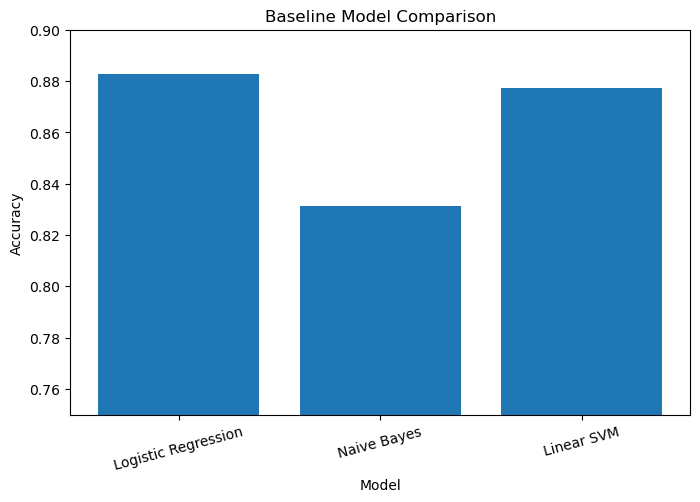

In [74]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Baseline Model Comparison")
plt.ylim(0.75, 0.90)
plt.xticks(rotation=15)

plt.show()

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_full = lr_full.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_full)

print(cm)

[[11043  1457]
 [ 1470 11030]]


## 8. Model Evaluation

The final Logistic Regression model and the χ²-selected Logistic Regression
model are evaluated using confusion matrices and classification metrics.

The confusion matrix provides a detailed view of correct and incorrect
positive and negative predictions.

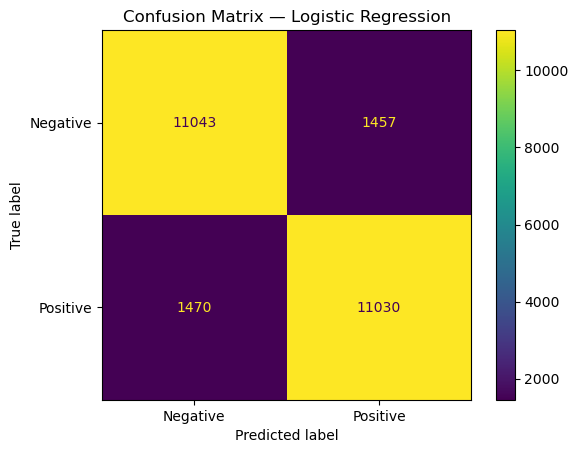

In [76]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

In [77]:
total = cm.sum()
correct = cm[0, 0] + cm[1, 1]
wrong = cm[0, 1] + cm[1, 0]

print("Correct predictions:", correct)
print("Wrong predictions:", wrong)
print("Error rate:", wrong / total)

Correct predictions: 22073
Wrong predictions: 2927
Error rate: 0.11708


In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_20k = lr_20k.predict(X_test_20k)

cm_20k = confusion_matrix(y_test, y_pred_20k)

print(cm_20k)

[[10990  1510]
 [ 1437 11063]]


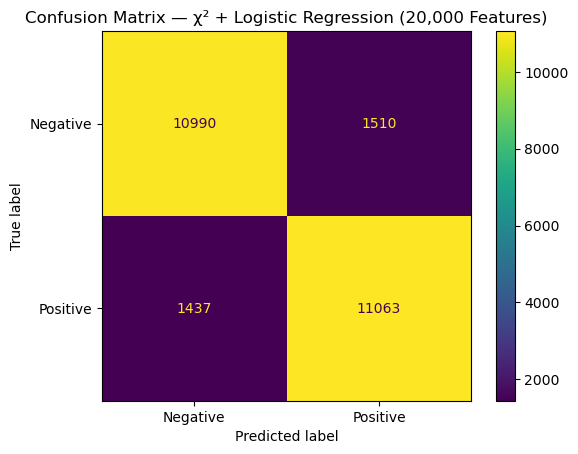

In [79]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_20k,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix — χ² + Logistic Regression (20,000 Features)")
plt.show()

In [80]:
from sklearn.metrics import classification_report

print("FULL MODEL")
print(classification_report(
    y_test,
    y_pred_full,
    target_names=["Negative", "Positive"]
))

print("\nCHI-SQUARE 20K MODEL")
print(classification_report(
    y_test,
    y_pred_20k,
    target_names=["Negative", "Positive"]
))

FULL MODEL
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


CHI-SQUARE 20K MODEL
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [81]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(chi_selector, "chi2_selector.pkl")
joblib.dump(lr_20k, "sentiment_model.pkl")

print("All 3 files saved successfully!")

All 3 files saved successfully!


## 9. Final Model and Prediction

Based on the feature-selection experiments, the 20,000-feature χ² model provides
a strong balance between dimensionality reduction and predictive performance.

The final prediction pipeline consists of:

**Raw Review → Preprocessing → TF-IDF → χ² Feature Selection → Logistic Regression**

The trained pipeline is also tested on a previously unseen movie review to
verify that it can perform end-to-end sentiment prediction.

In [82]:
new_review = """
This movie was absolutely fantastic. The story was engaging,
the acting was excellent, and I really enjoyed every minute of it.
"""

cleaned_review = preprocess_text(new_review)

review_tfidf = tfidf.transform([cleaned_review])

review_selected = chi_selector.transform(review_tfidf)

prediction = lr_20k.predict(review_selected)[0]

print("Prediction:", "Positive" if prediction == 1 else "Negative")

Prediction: Positive


## 10. Results and Conclusion

The baseline Logistic Regression model achieved an accuracy of **88.29%** using
74,849 TF-IDF features.

Applying χ² feature selection and retaining the top **20,000 features** reduced
the feature space by approximately **73.28%**, while achieving an accuracy of
**88.21%** and an F1-score of approximately **88.25%**.

This represents only a **0.08 percentage-point decrease in accuracy** compared
with the full-feature baseline.

The experiments indicate that a large proportion of the original TF-IDF feature
space can be removed without substantially affecting sentiment classification
performance. Performance also begins to plateau around 20,000 features, suggesting
that retaining substantially more features provides very limited additional
benefit.

### Key Findings

- Logistic Regression achieved the strongest baseline accuracy (**88.29%**).
- χ² feature selection reduced the feature space substantially.
- **20,000 features** provided an effective performance–dimensionality trade-off.
- The selected model retained approximately **99.91% of baseline accuracy**.
- Mutual Information was explored but was computationally expensive on the
  high-dimensional TF-IDF representation and was therefore not included in
  the final benchmark.

### Final Takeaway

Feature selection can make high-dimensional text representations considerably
more compact while preserving almost all of their predictive capability.

In [83]:
final_results = pd.DataFrame([
    {
        "Model": "Logistic Regression (Full TF-IDF)",
        "Features": 74849,
        "Accuracy": full_accuracy,
        "F1 Score": full_f1,
        "Feature Reduction (%)": 0
    },
    {
        "Model": "Logistic Regression + χ²",
        "Features": 20000,
        "Accuracy": 0.88212,
        "F1 Score": 0.8824632,
        "Feature Reduction (%)": 73.28
    }
])

final_results

,Model,Features,Accuracy,F1 Score,Feature Reduction (%)
0,Logistic Regression (Full TF-IDF),74849,0.88292,0.882859,0.00
1,Logistic Regression + χ²,20000,0.88212,0.882463,73.28


In [84]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Features": 74849,
        "Accuracy": 0.88292,
        "F1 Score": full_f1
    },
    {
        "Model": "Naive Bayes",
        "Features": 74849,
        "Accuracy": 0.83136,
        "F1 Score": 0.82
    },
    {
        "Model": "Linear SVM",
        "Features": 74849,
        "Accuracy": 0.87724,
        "F1 Score": 0.88
    },
    {
        "Model": "Logistic Regression + χ²",
        "Features": 20000,
        "Accuracy": 0.88212,
        "F1 Score": 0.8824632
    }
])

final_comparison

,Model,Features,Accuracy,F1 Score
0,Logistic Regression,74849,0.88292,0.882859
1,Naive Bayes,74849,0.83136,0.820000
2,Linear SVM,74849,0.87724,0.880000
3,Logistic Regression + χ²,20000,0.88212,0.882463
